# 📐 Notebook 2 — Statistiques Inférentielles & Régression

## Price Intelligence Platform | Pr. ELAACHAK | 2025-2026

### Objectifs
1. t-test : comparer les prix entre plateformes
2. ANOVA : comparer les catégories
3. Régression OLS : expliquer les variations de prix

In [3]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# statsmodels
try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
    print("✅ statsmodels disponible")
except:
    HAS_STATSMODELS = False
    print("⚠️ statsmodels non installé")

plt.rcParams.update({
    'figure.figsize': (12,6),
    'axes.grid': True
})

ALPHA = 0.05

✅ statsmodels disponible


In [4]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================

df = pd.read_csv(
    '../scrapers/data/cleaned_prices.csv'
)

print(df.shape)

df.head()

(2990, 7)


,name,price,category,source,url,scraped_at,source_label
0,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
1,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
2,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
3,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
4,Redmi Note 15 6GB 128GB Glacier Blue,2039.0,smartphones,jumia,https://www.jumia.ma/xiaomi-redmi-note-15-6gb-...,2026-03-30 10:27:13.506469 UTC,Jumia Maroc


In [5]:
df.columns

Index(['name', 'price', 'category', 'source', 'url', 'scraped_at',
       'source_label'],
      dtype='object')

In [6]:
df = df.rename(columns={
    'price': 'price_mad',
    'source': 'source_platform',
    'category': 'category_normalized'
})

df.head()

,name,price_mad,category_normalized,source_platform,url,scraped_at,source_label
0,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
1,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
2,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
3,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
4,Redmi Note 15 6GB 128GB Glacier Blue,2039.0,smartphones,jumia,https://www.jumia.ma/xiaomi-redmi-note-15-6gb-...,2026-03-30 10:27:13.506469 UTC,Jumia Maroc


In [8]:
print(df.columns)


Index(['name', 'price_mad', 'category_normalized', 'source_platform', 'url',
       'scraped_at', 'source_label'],
      dtype='object')


In [9]:
# Conversion de la date
df['scraped_at'] = pd.to_datetime(df['scraped_at'])

# Nombre de jours depuis la première date
df['days_since_start'] = (
    df['scraped_at'] - df['scraped_at'].min()
).dt.days

print("✅ Dates converties")

✅ Dates converties


In [10]:
df[['scraped_at', 'days_since_start']].head()

,scraped_at,days_since_start
0,2026-03-30 10:27:13.498929+00:00,0
1,2026-03-30 10:27:13.498929+00:00,0
2,2026-03-30 10:27:13.504469+00:00,0
3,2026-03-30 10:27:13.504469+00:00,0
4,2026-03-30 10:27:13.506469+00:00,0


In [11]:
jumia = df[df['source_platform']=='jumia']['price_mad']
marjane = df[df['source_platform']=='marjane']['price_mad']

t_stat, p_value = stats.ttest_ind(
    jumia,
    marjane,
    equal_var=False
)

print("t-stat =", t_stat)
print("p-value =", p_value)

if p_value < 0.05:
    print("✅ Différence significative")
else:
    print("❌ Pas de différence significative")

t-stat = -6.4779297152699655
p-value = 7.002784826521734e-10
✅ Différence significative


In [12]:
groups = []

for cat in df['category_normalized'].unique():
    groups.append(
        df[df['category_normalized']==cat]['price_mad']
    )

f_stat, p_value = stats.f_oneway(*groups)

print("F-stat =", f_stat)
print("p-value =", p_value)

if p_value < 0.05:
    print("✅ Différence entre catégories")
else:
    print("❌ Pas de différence")

F-stat = 262.8632761738663
p-value = 2.2011566639226267e-151
✅ Différence entre catégories


In [13]:
import statsmodels.formula.api as smf

model = smf.ols(
    'price_mad ~ days_since_start',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              price_mad   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     11.01
Date:                Sun, 24 May 2026   Prob (F-statistic):           0.000919
Time:                        21:18:34   Log-Likelihood:                -30166.
No. Observations:                2990   AIC:                         6.034e+04
Df Residuals:                    2988   BIC:                         6.035e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         3276.2713    109.923  

In [14]:
summary = df.groupby(
    ['category_normalized', 'source_platform']
)['price_mad'].agg(
    ['mean', 'median', 'std']
)

summary.to_csv(
    '../scrapers/data/inferential_stats_results.csv'
)

print("✅ CSV sauvegardé")

✅ CSV sauvegardé


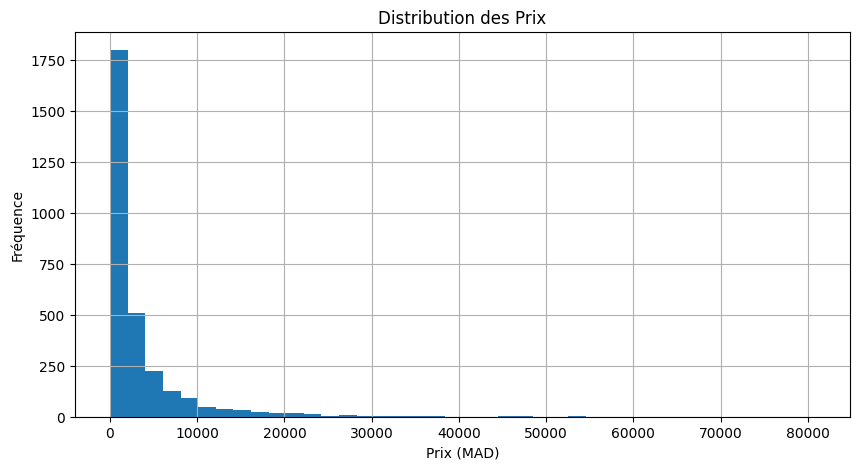

In [15]:
# ============================================================
# FIGURE 1 — Histogramme des prix
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['price_mad'], bins=40)

plt.title("Distribution des Prix")
plt.xlabel("Prix (MAD)")
plt.ylabel("Fréquence")

plt.show()

<Figure size 1000x600 with 0 Axes>

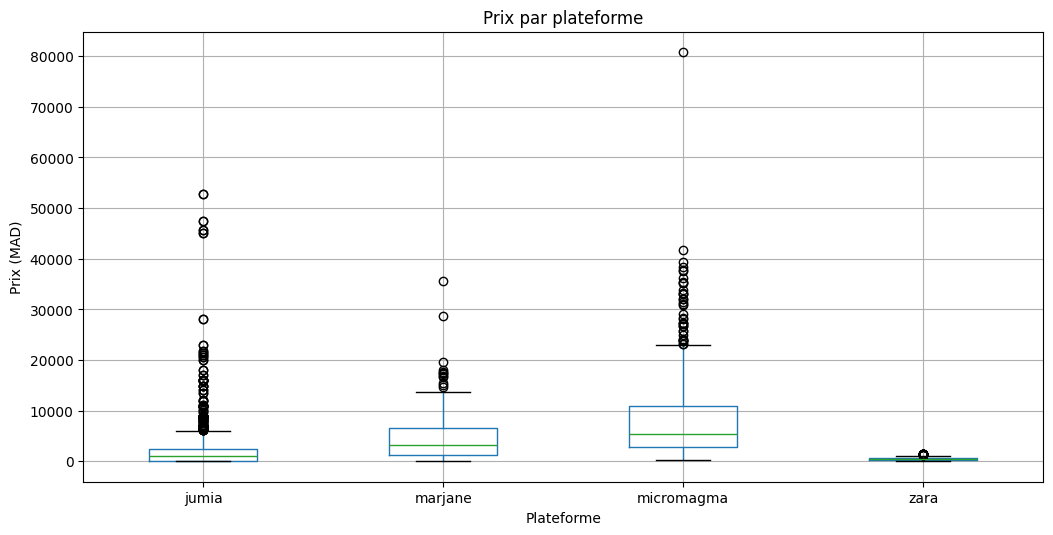

In [16]:
# ============================================================
# FIGURE 2 — Boxplot par plateforme
# ============================================================

plt.figure(figsize=(10,6))

df.boxplot(column='price_mad', by='source_platform')

plt.title("Prix par plateforme")
plt.suptitle("")

plt.xlabel("Plateforme")
plt.ylabel("Prix (MAD)")

plt.show()

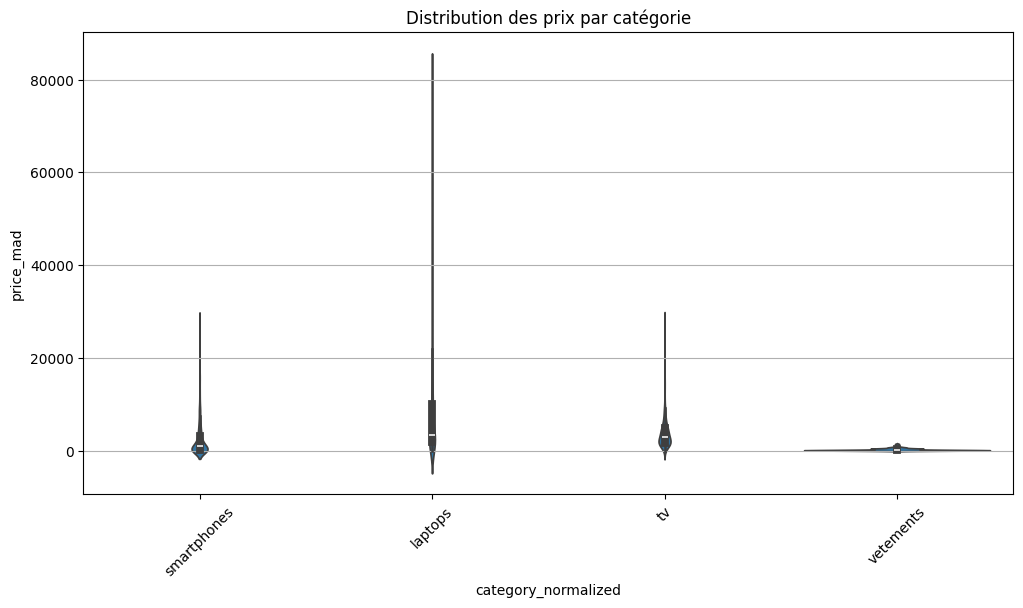

In [17]:
# ============================================================
# FIGURE 3 — Violinplot catégories
# ============================================================

import seaborn as sns

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='category_normalized',
    y='price_mad'
)

plt.title("Distribution des prix par catégorie")

plt.xticks(rotation=45)

plt.show()

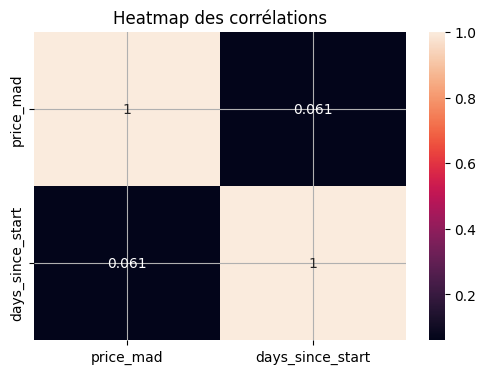

In [18]:
# ============================================================
# FIGURE 4 — Heatmap corrélations
# ============================================================

corr = df[['price_mad', 'days_since_start']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Heatmap des corrélations")

plt.show()

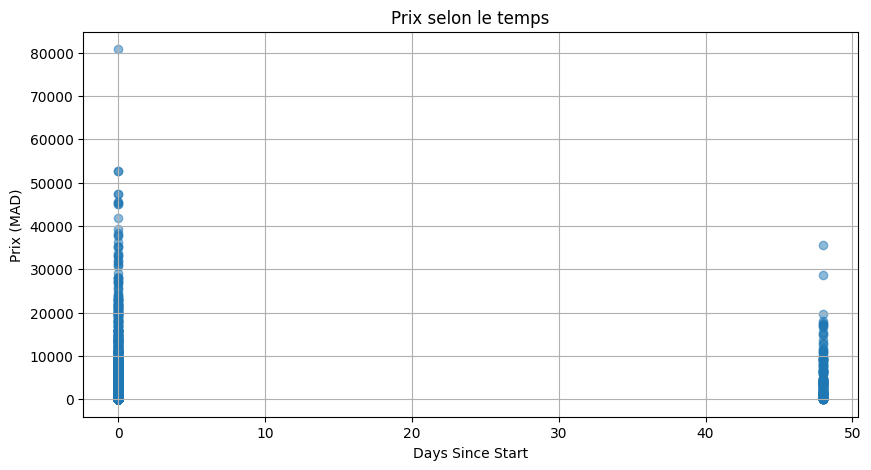

In [19]:
# ============================================================
# FIGURE 5 — Evolution des prix dans le temps
# ============================================================

plt.figure(figsize=(10,5))

plt.scatter(
    df['days_since_start'],
    df['price_mad'],
    alpha=0.5
)

plt.title("Prix selon le temps")
plt.xlabel("Days Since Start")
plt.ylabel("Prix (MAD)")

plt.show()

In [20]:
# ============================================================
# EXPORT CSV
# ============================================================

import os

os.makedirs('../data', exist_ok=True)

df.to_csv('../data/inferential_stats_results.csv', index=False)

print("✅ CSV exporté")

✅ CSV exporté
